In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
from scipy.stats import t,f
from scipy.stats import (
    jarque_bera,shapiro,
    kstest,anderson,skew,kurtosis
)

### Data Generation

In [3]:
np.random.seed(42)
n = 50
p = 3
X = np.random.randn(n, p)

beta = np.array([4.0, 2.5, -1.8]).reshape(-1, 1)  # slopes
bias = 7.5  # intercept
noise = np.random.normal(0, 1.5, size=(n, 1))

y = X @ beta + bias + noise

print(f"X shape: {X.shape}")        # (n, p)
print(f"beta shape: {beta.shape}")  # (p, 1)
print(f"y shape: {y.shape}")        # (n, 1)

X shape: (50, 3)
beta shape: (3, 1)
y shape: (50, 1)


In [4]:
np.random.randn(5,1).shape

(5, 1)

$$
\hat{w}=(X^\top X)^{-1}X^\top y \quad ; \quad \frac{\partial RSS}{\partial w} = -\frac{2}{n} X^\top (y - \hat{y})
$$

### Implementation : Gradient Descent and Closed Form Solution

In [5]:
import numpy as np
from scipy.stats import t,f
from scipy.stats import (
    jarque_bera,shapiro,
    kstest,anderson,skew,kurtosis
)
from statsmodels.stats.diagnostic import het_breuschpagan

class BaseLinearModel:
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.coef_ = None

    def _add_intercept(self, X):
        X = np.asarray(X)

        if self.fit_intercept:
            intercept = np.ones((X.shape[0], 1))
            return np.hstack((intercept, X))

        return X

    def predict(self, X):
        X = self._add_intercept(X)
        return X @ self.coef_

    def predict_one(self, x):
        x = np.asarray(x).ravel()

        if self.fit_intercept:
            x = np.hstack(([1.0], x))

        return x @ self.coef_


In [6]:
class LinearRegression(BaseLinearModel):
    def __init__(self, fit_intercept=True, lr=0.01, n_iterations=1000):
        super().__init__(fit_intercept)
        self.lr = lr
        self.n_iterations = n_iterations
        
    def fit(self, X, y):
        X = self._add_intercept(X)
        y = np.asarray(y)

        self.X = X
        self.y = y

        self.n_samples, self.n_features = X.shape

        # initialize weights
        self.coef_ = np.zeros((self.n_features, 1))

        for _ in range(self.n_iterations):

            predictions = X @ self.coef_
            residuals = y - predictions
            mse = np.sum(residuals**2)/self.n_samples
            print(f'Epoch = {_+1} ; MSE = {mse}')

            gradients = -(2 / self.n_samples) * (X.T @ residuals)
            self.coef_ -= self.lr * gradients

        self._compute_statistics()
        self._inference()
        self._f_test()
        self._diagnostics()
        self._information_criteria()

        return self

    def _compute_statistics(self):

        self.predictions = self.X @ self.coef_
        self.residuals = self.y - self.predictions

        self.rss = self.residuals.T @ self.residuals
        self.tss = np.sum((self.y - np.mean(self.y)) ** 2)

        self.r2 = 1 - self.rss / self.tss

        self.dof = self.n_samples - self.n_features
        self.sigma2 = self.rss / self.dof

        self.xtx_inv = np.linalg.pinv(self.X.T @ self.X)
        self.covariance_matrix = self.sigma2 * self.xtx_inv

        # adj_r2 
        adj_r2_numerator = (1 - self.r2) * (self.n_samples - 1)
        adj_r2_denominator = self.n_samples - self.n_features
        self.adj_r2 = 1 - (adj_r2_numerator / adj_r2_denominator)

        self.standard_errors = np.sqrt(np.diag(self.covariance_matrix))

    def _inference(self, alpha=0.05):

        beta = self.coef_.ravel()

        self.t_stats = beta / self.standard_errors
        self.p_values = 2 * (1 - t.cdf(np.abs(self.t_stats), df=self.dof))

        t_crit = t.ppf(1 - alpha / 2, df=self.dof)

        self.confidence_intervals = np.column_stack([
            beta - t_crit * self.standard_errors,
            beta + t_crit * self.standard_errors
        ])

    def _f_test(self):

        p = self.n_features - 1

        msr = (self.tss - self.rss) / p
        mse = self.rss / self.dof

        self.f_statistic = msr / mse
        self.f_p_value = 1 - f.cdf(self.f_statistic, p, self.dof)

    def _diagnostics(self):

        r = self.residuals.ravel()

        self.shapiro_p = shapiro(r).pvalue
        self.jarque_bera_p = jarque_bera(r).pvalue

        self.skewness = skew(r)
        self.kurtosis = kurtosis(r)

        self.durbin_watson = np.sum(np.diff(r) ** 2) / np.sum(r ** 2)

        bp_stat, bp_p, _, _ = het_breuschpagan(self.residuals.ravel(),self.X)

        self.breusch_pagan_stat = bp_stat
        self.breusch_pagan_p = bp_p

    def _information_criteria(self):

        n = self.n_samples
        k = self.n_features

        self.aic = n * np.log(self.rss / n) + 2 * k
        self.bic = n * np.log(self.rss / n) + k * np.log(n)

In [7]:
X.shape,y.shape

((50, 3), (50, 1))

In [8]:
np.random.seed(42)
model = LinearRegression()

In [9]:
model.fit(X,y)

Epoch = 1 ; MSE = 74.64256961549899
Epoch = 2 ; MSE = 71.83692622126564
Epoch = 3 ; MSE = 69.14686076952854
Epoch = 4 ; MSE = 66.56741592178611
Epoch = 5 ; MSE = 64.09385223433402
Epoch = 6 ; MSE = 61.72163842597482
Epoch = 7 ; MSE = 59.44644208541801
Epoch = 8 ; MSE = 57.26412079833362
Epoch = 9 ; MSE = 55.170713674941815
Epoch = 10 ; MSE = 53.16243325989762
Epoch = 11 ; MSE = 51.23565780706673
Epoch = 12 ; MSE = 49.38692390258568
Epoch = 13 ; MSE = 47.61291942036107
Epoch = 14 ; MSE = 45.91047679488874
Epoch = 15 ; MSE = 44.27656659696584
Epoch = 16 ; MSE = 42.7082913985298
Epoch = 17 ; MSE = 41.202879913488324
Epoch = 18 ; MSE = 39.757681402005645
Epoch = 19 ; MSE = 38.370160326284086
Epoch = 20 ; MSE = 37.037891246426604
Epoch = 21 ; MSE = 35.758553945488615
Epoch = 22 ; MSE = 34.52992877332467
Epoch = 23 ; MSE = 33.34989219931119
Epoch = 24 ; MSE = 32.21641256447925
Epoch = 25 ; MSE = 31.127546024023914
Epoch = 26 ; MSE = 30.08143267156918
Epoch = 27 ; MSE = 29.076292836961017
Epo

### Interpretation of weights 

In [10]:
model.coef_

array([[ 7.61168976],
       [ 4.20049575],
       [ 2.28878594],
       [-1.7993617 ]])

Suppose the estimated regression equation is:
$$
\text{Salary} = 200k + 50k(\text{Experience}) + 2k(\text{Hours}) + 30k(\text{Gender}) + 80k(\text{Masters}) + 150k(\text{PhD})
$$

 * Intercept ($\beta_0 = 200000$):The intercept represents the predicted salary when all explanatory variables are equal to zero.
 * Experience ($\beta_1 = 50000$): Holding all other variables constant, a one-year increase in experience is associated with an increase of ($\text{}50{,}000$) in annual salary.
 * Hours Worked ($\beta_2 = 2000$): Holding all other variables constant, each additional hour worked per week is associated with an increase of ($\text{}2{,}000$) in annual salary.
 * Gender ($\beta_3 = 30000$):Holding all other variables constant, male individuals earn, on average, ($\text{}30{,}000$) more than female individuals.
 * Education: Master's ($\beta_4 = 80000$):Holding all other variables constant, individuals with a Master's degree earn ($\text{}80{,}000$) more than those with a Bachelor's degree (the baseline category).
 * Education: PhD ($\beta_5 = 150000$):Holding all other variables constant, individuals with a PhD earn ($\text{}150{,}000$) more than those with a Bachelor's degree.


### Effect of changing units
 * **Changing units of input variable**: If Experience is measured in months instead of years (1 year = 12 months), the coefficient adjusts accordingly:
$\beta_1^{(\text{months})} = \frac{50000}{12} \approx 4167$. Thus, the interpretation becomes: a one-month increase in experience is associated with an increase of approximately ($\text{}4{,}167$) in salary.
 * **Rescaling the Response Variable** : If salary is expressed in lakhs of rupees (1 lakh = 100,000), the regression equation becomes:
 $\text{Salary} = 2 + 0.5(\text{Experience}) + 0.02(\text{Hours}) + 0.3(\text{Gender}) + 0.8(\text{Masters}) + 1.5(\text{PhD})$

### Standard Errors

In [11]:
model.standard_errors

array([0.19435547, 0.26827536, 0.19420611, 0.18900043])

$$
RSE = \sqrt{\frac{1}{n-p-1}RSS}  \quad ; \quad SE(\hat{\beta}_j) = RSE \cdot \sqrt{(X^\top X)^{-1} _{jj} }
$$

### $R^2$ & Adjusted $R^2$

In [12]:
model.r2, model.adj_r2

(array([[0.91986293]]), array([[0.9146366]]))

$$
R^2 = \frac{TSS - RSS}{TSS} \quad ; \quad \text{Adjusted } R^2=  1 - \frac{(1 - R^2)(N - 1)}{N - p - 1}
$$

 * The denominator $N - p - 1$ shrinks as the number of predictors $p$ grows.
 * This makes the fraction larger, which decreases Adjusted $R^2$ when unnecessary predictors are added.
 * Only predictors that substantially reduce RSS will cause Adjusted $R^2$ to increase.

### T - Statistics & F - Statistics

**Notes on Hypothesis Testing Terms** ; 
 * **alpha** = P(Reject $H_0$ ∣ $H_0$ is true) ; we accept a 5% risk of falsely rejecting the null hypothesis
 * **beta** = P(Fail to reject $H_0$ ∣ $H_0$ is false)
 * **Power** measures the ability of a test to correctly detect a true effect. $1-\beta$
 * **p-value** is the probability of observing results at least as extreme as the observed data, assuming the null hypothesis is true.

In [13]:
model.t_stats

array([39.16375455, 15.65740391, 11.78534434, -9.52041046])

$$
t = \frac{\hat{\beta}_1 - 0}{SE(\hat{\beta}_1)} \quad ; \quad F = \frac{\frac{TSS-RSS}{p}}{\frac{RSS}{n-p-1}}
$$ 

 * t has n-p-1 degrees of freedom
 * f has (p,n-p-1) degrees of freedom

In [14]:
model.p_values

array([0.00000000e+00, 0.00000000e+00, 1.77635684e-15, 1.89714910e-12])

In [15]:
model.f_statistic

array([[176.0054914]])

In [16]:
model.f_p_value

array([[0.]])

### Confidence Intervals 

 * A 95% confidence interval means that if we repeatedly took samples and constructed intervals in the same way, approximately 95% of those intervals would contain the true parameter value.
 * Confidence intervals for the feature coefficients can be constructred using : $\hat{\beta}_j \pm t_{\alpha/2,\, n-p-1} \cdot SE(\hat{\beta}_j)$

In [17]:
model.confidence_intervals

array([[ 7.2204725 ,  8.00290702],
       [ 3.66048545,  4.74050605],
       [ 1.8978693 ,  2.67970257],
       [-2.17979984, -1.41892356]])

### Non-Normality of Errors 
 * Violates the assumption that residuals are normally distributed.
 * common sources : outliers
 * Remedies : Box - Cox log Transformations.
 * Shapiro Wilk Test  & Jarque Bera Test
 * Null Hypothesis Test : Residuals are normally distributed
 * **Shapiro-Wilk Test for Normality**
    * Tests whether residuals follow a normal distribution.
    * Null hypothesis: residuals are normally distributed.
    * Particularly powerful for small sample sizes ($n < 50$).
 * **Kolmogorov-Smirnov Test for Normality**
   * Compares the empirical distribution of residuals to a theoretical normal CDF.
   * Null hypothesis: residuals follow the normal distribution.
   * Sensitive to differences in both shape and location.
 * **Anderson-Darling Test for Normality**
   * A refinement of the K--S test with extra sensitivity to tail behavior.
   * Null hypothesis: residuals are normally distributed.
   * Strong at detecting heavy tails or deviations in extremes.

In [18]:
model.shapiro_p

np.float64(0.14114506220886883)

In [19]:
model.jarque_bera_p

np.float64(0.25085282138966564)

### Breusch Pagan : Checking Homoscedasticity
 * Heteroskedasticity refers to non-constant variance of the error term across observations.
 * This causes inefficient and biased standard errors, leading to unreliable hypothesis tests.
 * Breusch pagan test, scale location plot are useful for detecting heteroskedasticity. 
 * Tests whether error variance is constant.
 * Null hypothesis: homoscedastic errors.
 * Alternative: heteroskedasticity dependent on predictors.
 * $\hat{\varepsilon}_i^{\,2} = \gamma_0 + \gamma_1 x_{i1} + \cdots + \gamma_p x_{ip} + u_i$
 * $W = n R_{\text{aux}}^{2}, \quad : \quad W \sim \chi^2_{p}$

In [20]:
model.breusch_pagan_p,model.breusch_pagan_stat

(np.float64(0.5779684272036025), np.float64(1.9732924171469601))

### Durbin Watson : Checking First order Autocorrelation 
 * Autocorrelation occurs when error terms are correlated across time (common in time series data).
 * Violates independence of errors, leading to underestimated standard errors.
 * Detects first-order autocorrelation in residuals (commonly in time-series data).
 * Null hypothesis: no first-order autocorrelation.
 * $d = \frac{\sum_{t=2}^{T} (e_t - e_{t-1})^{2}}{\sum_{t=1}^{T} e_t^{2}}$
 * $d \approx 2$: no autocorrelation.
 * $d < 1.5$: positive autocorrelation.
 * $d > 2.5$: negative autocorrelation.

In [21]:
model.durbin_watson

np.float64(1.9624588472904438)

### Variance Inflation Factor 
 * Used for getting features with multi-collinearity
 * Multicollinearity increases the variance of coefficient estimates, making confidence intervals wider.
 * diagnosis : coefficients signs differ from expectations
 * diagnosis : adding or removing a feature causes drastic changes in coefficients.
 * Solution : Combine correlated features, remove reducntant featurs 
 * VIF is one way to find those multi-collinear features. 
 * $VIF_j = \frac{1}{1 - R_j^{2}}$
 * where $R_j^{2}$ is obtained from regressing predictor $X_j$ on all other predictors.
 * $VIF = 1$: no multicollinearity.
 * $VIF > 5$: moderate multicollinearity concern.
 * $VIF > 10$: severe multicollinearity.


In [22]:
for i in range(X.shape[1]):
    target = X[:,i].reshape(-1,1)
    features = np.delete(X,i,axis=1) # remaining featues
    print(target.shape,features.shape)

(50, 1) (50, 2)
(50, 1) (50, 2)
(50, 1) (50, 2)


In [23]:
def compute_vif(X):
    X = np.asarray(X)
    n_features = X.shape[1]
    vif_scores = []
    for i in range(n_features):

        y = X[:, i] # target feature
        X_other = np.delete(X, i, axis=1) # remaining features

        # add intercept
        intercept = np.ones((X_other.shape[0], 1))
        X_other = np.hstack((intercept, X_other))

        beta = np.linalg.pinv(X_other.T @ X_other) @ (X_other.T @ y)
        y_pred = X_other @ beta

        rss = np.sum((y - y_pred) ** 2)
        tss = np.sum((y - np.mean(y)) ** 2)

        r2 = 1 - (rss / tss)
        vif = 1 / (1 - r2)
        vif_scores.append(vif)
    return np.array(vif_scores)

In [24]:
compute_vif(X)

array([1.08731735, 1.03213512, 1.06231609])

### Scale Location Plot for checking Heteroscedasticity
 * The Scale-Location Plot (also called the Spread-Location Plot) is a residual diagnostic plot used to check heteroscedasticity.
 * whether residual variance is approximately constant across fitted values.
 * Plots $\sqrt{|e_i|}$ against fitted values

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def scale_location_plot(y_true, y_pred, n_features):
    residuals = y_true - y_pred
    dof = len(y_true) - n_features

    # residual standard error
    sigma = np.sqrt(np.sum(residuals**2) / dof)

    # standardized residuals
    standardized_residuals = residuals / sigma

    # transformed residuals
    scale_location = np.sqrt(np.abs(standardized_residuals))

    # plot
    plt.figure(figsize=(6, 4))

    plt.scatter(y_pred, scale_location)

    plt.xlabel("Fitted Values")
    plt.ylabel("Sqrt(|Standardized Residuals|)")
    plt.title("Scale-Location Plot")

    plt.show()

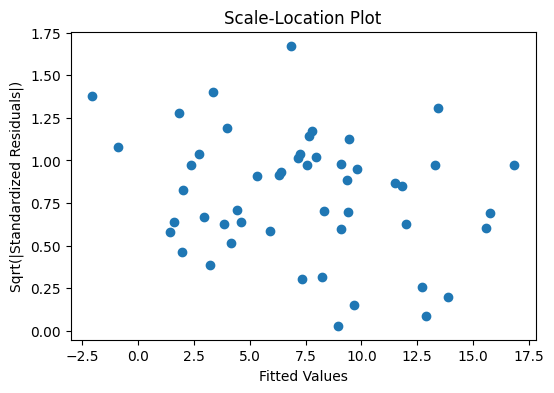

In [26]:
scale_location_plot(model.y,model.predictions,model.n_features)

### Leverage 
 * how unusual a point’s predictor values are.
 * A point far away in feature space has high leverage.
 * $H = X(X^TX)^{-1}X^T$
 * The diagnonal elements of the hat matrix, $h_{ii}$ are called leverage values
 * High leverage points correspond to observations with unsual predictor values.
 * if $h_{ii} > \frac{2p}{n}$ then the observation is considered a high leverage point. 

### Cook's Distance
 * How much the fitted model changes if observation is removed. 
 * It combines residual magnitude and leverage
$$
D_i =
\frac{e_i^2}{p \cdot MSE}
\cdot
\frac{h_{ii}}{(1-h_{ii})^2}
$$
 * $e_i$ = residual for observation $i$
 * $h_{ii}$ = leverage of observation $i$
 * $p$ = number of parameters (including intercept)
 * $MSE = \dfrac{RSS}{n-p}$
 * $D_i>1$ may indicate a highly influential point. 

In [30]:

def leverage_and_cooks_distance(X, y, y_pred):

    X = np.asarray(X)
    y = np.asarray(y).ravel()
    y_pred = np.asarray(y_pred).ravel()

    n, p = X.shape

    # residuals
    residuals = y - y_pred

    # MSE
    rss = np.sum(residuals ** 2)
    mse = rss / (n - p)

    # Hat matrix
    H = X @ np.linalg.pinv(X.T @ X) @ X.T

    # leverage values
    leverage = np.diag(H)

    # Cook's distance
    cooks_distance = (
        (residuals ** 2 / (p * mse))
        * (leverage / (1 - leverage) ** 2)
    )

    return leverage, cooks_distance

In [31]:
X_design = model._add_intercept(X)
print(X_design.shape)

y_pred = model.predict(X) 
leverage,cooks = leverage_and_cooks_distance(
    X_design,y,y_pred
)

(50, 4)


In [32]:
leverage

array([0.04729753, 0.11272512, 0.14730281, 0.03443254, 0.14064365,
       0.05099051, 0.11788245, 0.05879514, 0.05789901, 0.02991505,
       0.10093832, 0.10562121, 0.12155786, 0.04210357, 0.06084291,
       0.05677269, 0.07914905, 0.03813097, 0.09673568, 0.04557039,
       0.05403662, 0.10231543, 0.0507979 , 0.07722014, 0.18881711,
       0.05044768, 0.09164004, 0.08376886, 0.05717283, 0.03686495,
       0.05035475, 0.06871664, 0.02942937, 0.06319859, 0.03583322,
       0.1235982 , 0.08149824, 0.14988154, 0.02378471, 0.09292287,
       0.11026426, 0.15874665, 0.06155853, 0.07611419, 0.08483062,
       0.1156674 , 0.06990627, 0.12341307, 0.06050298, 0.0813899 ])

In [33]:
p = (2*model.n_features)/model.n_samples
print(f'p = {p}')
leverage>p

p = 0.16


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [34]:
cooks

array([1.29387083e-04, 5.55777688e-05, 4.57490498e-02, 4.63832733e-06,
       3.97324793e-04, 1.27583294e-02, 1.36615062e-01, 3.94191801e-03,
       2.77611074e-02, 1.95523723e-03, 1.92264323e-02, 3.81986636e-02,
       2.95102770e-02, 9.42310404e-03, 1.57705268e-02, 2.67288430e-03,
       5.89236560e-03, 4.00413893e-02, 3.87543848e-03, 8.43126523e-03,
       1.58954443e-02, 1.48290649e-02, 1.06325506e-08, 4.52862573e-03,
       1.61843199e-02, 7.38082295e-03, 4.26414108e-03, 7.26795936e-02,
       1.80340148e-03, 7.79690741e-02, 7.81478429e-03, 2.16205681e-02,
       1.26541272e-02, 1.27710724e-03, 1.57793186e-03, 3.58101759e-02,
       3.73392794e-03, 1.18398476e-03, 5.58034220e-03, 5.61870489e-02,
       2.44175880e-02, 7.61307930e-02, 7.93773783e-04, 5.93072535e-02,
       2.94813767e-03, 1.89934849e-06, 3.82052617e-02, 5.11266117e-03,
       7.48773133e-05, 2.77432250e-02])

In [35]:
cooks>1

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

### Akaike Information Criterion (AIC) & Bayesian Information Criterion (BIC)
 * In linear regression, AIC and BIC are fundamentally measuring how well the model explains the residuals, while penalizing model complexity.Smaller RSS implies higher likelihood which implies lower AIC/BIC
 * Akaike Information Criterion (AIC) : AIC is a model selection criterion used to compare different regression models. It balances:goodness of fit & model complexity. Lower AIC indicates a better model. AIC favours the models with better predictive power even if they are slighly complex. 
   $$
   AIC = -2 \log(L) + 2k
   $$

 * Bayesian Information Criterion (BIC) : Similar to AIC but applies a stronger penalty for model complexity. Lower BIC indicates better model. 

   $$
   BIC = -2 \log(L) + k\log(n)
   $$

 * AIC & BIC are used for comparing multiple regression models,feature selection and avoiding overfitting.
 * Here L is the probability of observing this data given the estimated parameters. 
 * In Ordinary linear regression; the likelihood is proportional to $RSS/n$. 

In [36]:
model.aic , model.bic

(array([[34.06777026]]), array([[41.71586228]]))

### Single Sample Prediction

In [37]:
sample = np.array([-0.90802408, -1.4123037 ,  1.46564877]).reshape(-1,1)
sample.shape

(3, 1)

In [38]:
model.predict_one(sample)

array([-2.07215464])

### Batch Prediction

In [39]:
test_data = X[:5]
test_data.shape

(5, 3)

In [40]:
test_data

array([[ 0.49671415, -0.1382643 ,  0.64768854],
       [ 1.52302986, -0.23415337, -0.23413696],
       [ 1.57921282,  0.76743473, -0.46947439],
       [ 0.54256004, -0.46341769, -0.46572975],
       [ 0.24196227, -1.91328024, -1.72491783]])

In [41]:
model.predict(test_data)

array([[ 8.21625211],
       [13.89454032],
       [16.84641453],
       [ 9.6680633 ],
       [ 7.35271343]])

### Correlation & Covariance

$$ 
S_{xy} = \sum{(x-\bar{x})(y-\bar{y}} \quad ; \quad Cov = \frac{S_{xy}}{N}  \quad ; \quad r = \frac{S_{xy}}{\sqrt{S_{xx} S_{yy}}}
$$ 

In [42]:
np.random.seed(101)
x = np.random.randn(10,1)
y = np.random.randn(10,1)
x,y

(array([[ 2.70684984],
        [ 0.62813271],
        [ 0.90796945],
        [ 0.50382575],
        [ 0.65111795],
        [-0.31931804],
        [-0.84807698],
        [ 0.60596535],
        [-2.01816824],
        [ 0.74012206]]),
 array([[ 0.52881349],
        [-0.58900053],
        [ 0.18869531],
        [-0.75887206],
        [-0.93323722],
        [ 0.95505651],
        [ 0.19079432],
        [ 1.97875732],
        [ 2.60596728],
        [ 0.68350889]]))

In [43]:
def covariance(x,y):
    s_xy = np.sum((x-x.mean())*(y-y.mean()))
    N = len(x)
    return s_xy/N

In [44]:
covariance(x,y)

np.float64(-0.5504331676962857)

In [45]:
def correlation(x,y):
    s_xx = np.sum((x-np.mean(x))**2)
    s_yy = np.sum((y-np.mean(y))**2)
    s_xy = np.sum((x-np.mean(x))*(y-np.mean(y)))
    return s_xy/np.sqrt(s_xx*s_yy)

In [46]:
correlation(x,y)

np.float64(-0.43043512470649875)

### Regularization

- OLS: unbiased, high variance under multicollinearity
- Ridge: L2 shrinkage, stable, no sparsity
- Lasso: L1 induces sparsity (feature selection)
- Elastic Net: combines L1 + L2, robust for correlated features
- Always standardize features before regularization
- Intercept is never regularized
- Lasso is non-smooth → coordinate descent preferred over GD
- Large coefficients make the model highly sensitive to small changes in the input features, causing unstable predictions and overfitting.
 - By shrinking coefficients toward zero, regularization forces the model to rely only on strong, stable patterns in the data rather than noise.

### Ridge - L2 
 * Objective : $\min_\beta \|y - X\beta\|^2 + \lambda \|\beta\|^2$
 * Closed Form Solution : $\hat{\beta} = (X^T X + \lambda I)^{-1} X^T y $
 * Gradient Descent Solution : $\nabla = -2X^T (y - X\beta) + 2\lambda \beta$

In [47]:
class RidgeRegression(BaseLinearModel):
    def __init__(self, alpha=1.0, lr=0.01, n_iterations=1000,fit_intercept=True):

        super().__init__(fit_intercept)

        self.alpha = alpha
        self.lr = lr
        self.n_iterations = n_iterations


    def fit(self, X, y):

        X = self._add_intercept(X)
        y = np.asarray(y)

        self.X = X
        self.y = y

        self.n_samples, self.n_features = X.shape
        self.coef_ = np.zeros((self.n_features, 1))

        for i in range(self.n_iterations):

            predictions = X @ self.coef_
            residuals = y - predictions

            mse = np.sum(residuals**2)/self.n_samples
            print(f'Epoch = {i+1} ; MSE = {mse}')

            # OLS gradient
            grad = -(2 / self.n_samples) * (X.T @ residuals)

            # Ridge penalty (do NOT regularize intercept)
            penalty = 2 * self.alpha * self.coef_
            penalty[0] = 0
    
            grad += penalty

            self.coef_ -= self.lr * grad


        return self

In [48]:
np.random.seed(42)
n = 50
p = 3
X = np.random.randn(n, p)


beta = np.array([4.0, 2.5, -1.8]).reshape(-1, 1)  # slopes
bias = 7.5  # intercept
noise = np.random.normal(0, 1.5, size=(n, 1))

y = X @ beta + bias + noise

print(f"X shape: {X.shape}")        # (n, p)
print(f"beta shape: {beta.shape}")  # (p, 1)
print(f"y shape: {y.shape}")        # (n, 1)

X shape: (50, 3)
beta shape: (3, 1)
y shape: (50, 1)


In [49]:
model = RidgeRegression()
model.fit(X,y)

Epoch = 1 ; MSE = 74.64256961549899
Epoch = 2 ; MSE = 71.83692622126564
Epoch = 3 ; MSE = 69.16005087195627
Epoch = 4 ; MSE = 66.60527429479848
Epoch = 5 ; MSE = 64.16632391882321
Epoch = 6 ; MSE = 61.83729709511917
Epoch = 7 ; MSE = 59.61263630058242
Epoch = 8 ; MSE = 57.48710616955356
Epoch = 9 ; MSE = 55.45577221034233
Epoch = 10 ; MSE = 53.51398107520758
Epoch = 11 ; MSE = 51.65734226297611
Epoch = 12 ; MSE = 49.881711143225246
Epoch = 13 ; MSE = 48.18317319989591
Epoch = 14 ; MSE = 46.55802940040829
Epoch = 15 ; MSE = 45.00278260388608
Epoch = 16 ; MSE = 43.51412492901039
Epoch = 17 ; MSE = 42.08892600837384
Epoch = 18 ; MSE = 40.72422206203476
Epoch = 19 ; MSE = 39.41720572832544
Epoch = 20 ; MSE = 38.16521659488421
Epoch = 21 ; MSE = 36.96573237739745
Epoch = 22 ; MSE = 35.81636069768549
Epoch = 23 ; MSE = 34.714831416577134
Epoch = 24 ; MSE = 33.65898948051931
Epoch = 25 ; MSE = 32.646788244085656
Epoch = 26 ; MSE = 31.676283233505067
Epoch = 27 ; MSE = 30.74562631904935
Epoch 

### Lasso - L1 Regularization
* Objective : $\min_\beta \|y - X\beta\|^2 + \lambda \|\beta\|_1$
* Closed Form Solution : No closed-form solution
* Gradient (Subgradient) : $\nabla = -2X^T (y - X\beta) + \lambda \, \text{sign}(\beta)$

In [50]:
class LassoRegression(BaseLinearModel):
    def __init__(self, alpha=1.0, lr=0.01, n_iterations=1000, fit_intercept=True):
        super().__init__(fit_intercept)

        self.alpha = alpha
        self.lr = lr
        self.n_iterations = n_iterations

    def fit(self, X, y):

        X = self._add_intercept(X)
        y = np.asarray(y)

        self.X = X
        self.y = y

        self.n_samples, self.n_features = X.shape
        self.coef_ = np.zeros((self.n_features, 1))

        for i in range(self.n_iterations):

            predictions = X @ self.coef_
            residuals = y - predictions

            mse = np.mean(residuals ** 2)
            print(f"Epoch = {i+1} ; MSE = {mse}")

            # OLS gradient
            grad = -(2 / self.n_samples) * (X.T @ residuals)

            # L1 penalty (subgradient)
            penalty = self.alpha * np.sign(self.coef_)
            penalty[0] = 0   # do not regularize intercept

            grad += penalty

            self.coef_ -= self.lr * grad

        return self

In [51]:
model = LassoRegression()
model.fit(X,y)

Epoch = 1 ; MSE = 74.64256961549899
Epoch = 2 ; MSE = 71.83692622126564
Epoch = 3 ; MSE = 69.27343269570196
Epoch = 4 ; MSE = 66.81395731979599
Epoch = 5 ; MSE = 64.45408106125046
Epoch = 6 ; MSE = 62.189577638873914
Epoch = 7 ; MSE = 60.01640496829087
Epoch = 8 ; MSE = 57.93069699206424
Epoch = 9 ; MSE = 55.92875587678953
Epoch = 10 ; MSE = 54.007044560517954
Epoch = 11 ; MSE = 52.16217963462581
Epoch = 12 ; MSE = 50.39092454497329
Epoch = 13 ; MSE = 48.69018309788771
Epoch = 14 ; MSE = 47.05699325716736
Epoch = 15 ; MSE = 45.48852121893102
Epoch = 16 ; MSE = 43.98205575174066
Epoch = 17 ; MSE = 42.53500278999748
Epoch = 18 ; MSE = 41.14488026915881
Epoch = 19 ; MSE = 39.80931319184587
Epoch = 20 ; MSE = 38.526028914409906
Epoch = 21 ; MSE = 37.29285264400014
Epoch = 22 ; MSE = 36.107703136630015
Epoch = 23 ; MSE = 34.96858858717089
Epoch = 24 ; MSE = 33.87360270261573
Epoch = 25 ; MSE = 32.820920950348466
Epoch = 26 ; MSE = 31.808796973531386
Epoch = 27 ; MSE = 30.835559166080944
Epo

### Elastic Regularization
* Objective : $\min_\beta \|y - X\beta\|^2 + \lambda_1 \|\beta\|_1 + \lambda_2 \|\beta\|^2$
* Closed Form Solution : No closed-form solution
* Gradient Descent Solution :$\nabla = -2X^T (y - X\beta) + \lambda_1 \text{sign}(\beta) + 2\lambda_2 \beta$

In [52]:
class ElasticNetRegression(BaseLinearModel):
    def __init__(self, alpha=1.0, l1_ratio=0.5, lr=0.01,
                 n_iterations=1000, fit_intercept=True):

        super().__init__(fit_intercept)

        self.alpha = alpha
        self.l1_ratio = l1_ratio   # mix between L1 and L2
        self.lr = lr
        self.n_iterations = n_iterations

    def fit(self, X, y):

        X = self._add_intercept(X)
        y = np.asarray(y)

        self.X = X
        self.y = y

        self.n_samples, self.n_features = X.shape
        self.coef_ = np.zeros((self.n_features, 1))

        l1 = self.alpha * self.l1_ratio
        l2 = self.alpha * (1 - self.l1_ratio)

        for i in range(self.n_iterations):

            predictions = X @ self.coef_
            residuals = y - predictions

            mse = np.mean(residuals ** 2)
            print(f"Epoch = {i+1} ; MSE = {mse}")

            # OLS gradient
            grad = -(2 / self.n_samples) * (X.T @ residuals)

            # Elastic Net penalty
            l1_penalty = l1 * np.sign(self.coef_)
            l2_penalty = 2 * l2 * self.coef_

            # do not regularize intercept
            l1_penalty[0] = 0
            l2_penalty[0] = 0

            grad += (l1_penalty + l2_penalty)

            self.coef_ -= self.lr * grad

        return self

In [53]:
model = ElasticNetRegression()
model.fit(X,y)

Epoch = 1 ; MSE = 74.64256961549899
Epoch = 2 ; MSE = 71.83692622126564
Epoch = 3 ; MSE = 69.21668312329535
Epoch = 4 ; MSE = 66.70885020900656
Epoch = 5 ; MSE = 64.30822952902126
Epoch = 6 ; MSE = 62.00988197226999
Epoch = 7 ; MSE = 59.809113457003576
Epoch = 8 ; MSE = 57.70146190276112
Epoch = 9 ; MSE = 55.682684937096276
Epoch = 10 ; MSE = 53.74874829368542
Epoch = 11 ; MSE = 51.89581486108838
Epoch = 12 ; MSE = 50.12023434391298
Epoch = 13 ; MSE = 48.41853350046099
Epoch = 14 ; MSE = 46.78740692311482
Epoch = 15 ; MSE = 45.2237083297702
Epoch = 16 ; MSE = 43.724442336538715
Epoch = 17 ; MSE = 42.28675668374372
Epoch = 18 ; MSE = 40.907934888921666
Epoch = 19 ; MSE = 39.58538930212374
Epoch = 20 ; MSE = 38.31665454029907
Epoch = 21 ; MSE = 37.09938127893408
Epoch = 22 ; MSE = 35.9313303804308
Epoch = 23 ; MSE = 34.81036733993365
Epoch = 24 ; MSE = 33.73445703046656
Epoch = 25 ; MSE = 32.701658730322684
Epoch = 26 ; MSE = 31.710121416663615
Epoch = 27 ; MSE = 30.758079310237523
Epoch